=== EVALUACIÓN ESTRICTA EN SUBCOHORTE ONCOLÓGICA Y CORRECCIÓN DE PRIOR ===
Cargando dataset de prueba oncológico...

[Cargando Modelo] MORTALIDAD (Random Forest)...

------------------------------------------------------------
--- Resultados para MORTALIDAD ---
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.88      0.93     91632
           1       0.29      0.76      0.42      5920

    accuracy                           0.87     97552
   macro avg       0.64      0.82      0.68     97552
weighted avg       0.94      0.87      0.90     97552

F1-Score (Clase 1): 0.4220
F1-Score (Macro): 0.6758
AUPRC (Corregido): 0.4223
AUC-ROC (Corregido): 0.9202
Brier Score (Corregido): 0.0475


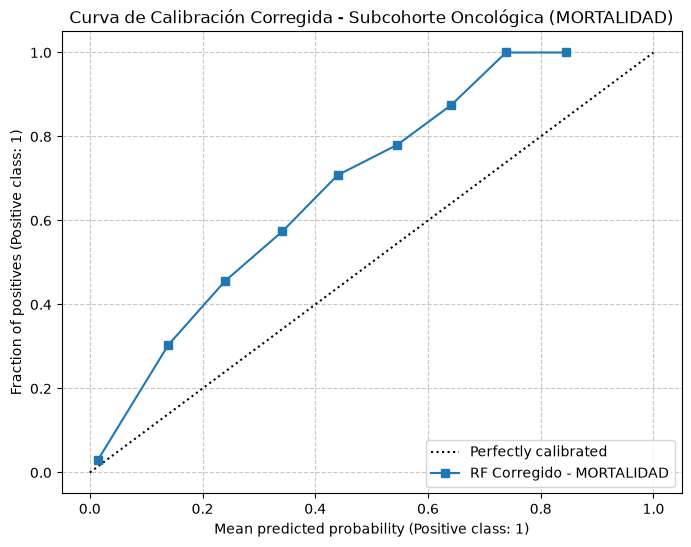


[Cargando Modelo] SEVERIDAD (XGBoost)...

------------------------------------------------------------
--- Resultados para SEVERIDAD ---
------------------------------------------------------------


/usr/lib/python3.12/pickle.py:1710: UserWarning: [04:38:04] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


              precision    recall  f1-score   support

           0       0.94      0.95      0.94     11713
           1       0.73      0.77      0.75     25360
           2       0.67      0.65      0.66     33550
           3       0.76      0.74      0.75     26929

    accuracy                           0.74     97552
   macro avg       0.78      0.78      0.78     97552
weighted avg       0.74      0.74      0.74     97552

F1-Score (Macro): 0.7776
AUPRC (OvR Weighted): 0.8222
AUC-ROC (OvR Weighted): 0.9104
Brier Score (Multiclase): 0.0859


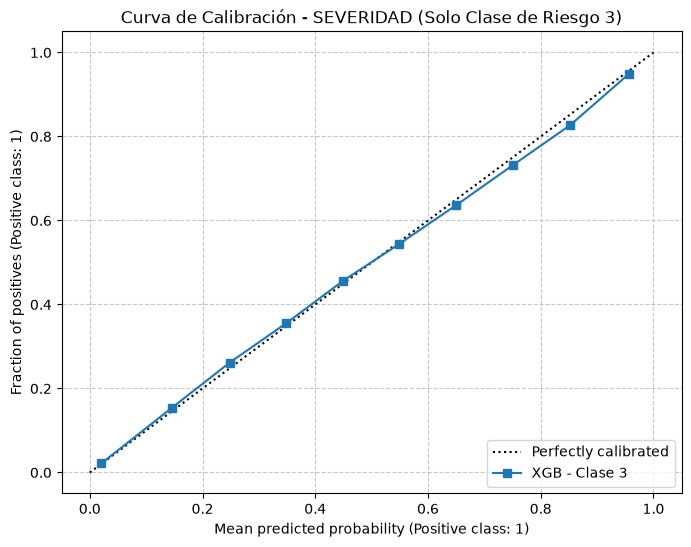


[Cargando Modelo] CONSUMO_RECURSOS (XGBoost)...

------------------------------------------------------------
--- Resultados para CONSUMO_RECURSOS ---
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.81      0.69      0.75      9220
           1       0.68      0.63      0.65     28154
           2       0.83      0.89      0.86     60178

    accuracy                           0.79     97552
   macro avg       0.78      0.73      0.75     97552
weighted avg       0.79      0.79      0.79     97552

F1-Score (Macro): 0.7532
AUPRC (OvR Weighted): 0.8719
AUC-ROC (OvR Weighted): 0.9018
Brier Score (Multiclase): 0.0938


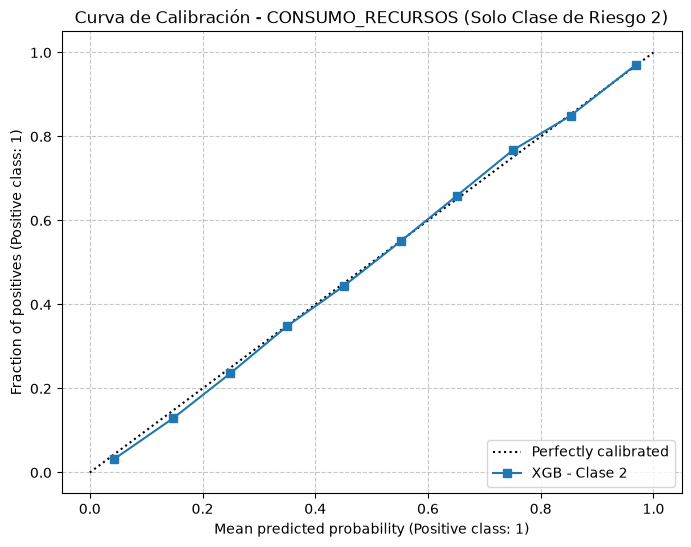

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    f1_score, average_precision_score, roc_auc_score, 
    brier_score_loss, classification_report
)
from sklearn.calibration import CalibrationDisplay

# 1. Rutas
dir_datos = "../../Datos/Datasets Finales"
dir_rf = "../../Resultados/Resultados (etapa 3 y 4)/Random_Forest"
dir_xgb = "../../Resultados/Resultados (etapa 3 y 4)/XGBoost"

print("=== EVALUACIÓN ESTRICTA EN SUBCOHORTE ONCOLÓGICA Y CORRECCIÓN DE PRIOR ===")

# 2. Cargar SOLO Prueba Oncológica
print("Cargando dataset de prueba oncológico...")
df_onco_test = pd.read_csv(os.path.join(dir_datos, "dataset_prueba_onco.csv"), low_memory=False)

# 3. Función matemática para la corrección de probabilidades (Desplazamiento Logarítmico)
def corregir_probabilidades(p_pred, prevalencia_entrenamiento, prevalencia_prueba):
    """
    Aplica el desplazamiento logarítmico de la razón de prevalencias 
    (Prior Correction) solicitado por el profesor.
    """
    # Evitar logaritmo de cero
    p_pred = np.clip(p_pred, 1e-15, 1 - 1e-15)
    
    # Calcular los log-odds
    log_odds_pred = np.log(p_pred / (1 - p_pred))
    log_odds_train = np.log(prevalencia_entrenamiento / (1 - prevalencia_entrenamiento))
    log_odds_test = np.log(prevalencia_prueba / (1 - prevalencia_prueba))
    
    # Desplazar el intercepto
    log_odds_corregido = log_odds_pred + log_odds_test - log_odds_train
    
    # Devolver a probabilidad (Sigmoide)
    p_corregido = 1 / (1 + np.exp(-log_odds_corregido))
    return p_corregido

# 4. Función de Evaluación Multiclase con Calibración
def evaluar_modelo(modelo, X, y_true, target_name, is_multiclass=False, clase_interes=1):
    print(f"\n{'-'*60}\n--- Resultados para {target_name.upper()} ---\n{'-'*60}")
    
    y_pred = modelo.predict(X)
    y_prob = modelo.predict_proba(X)
    
    print(classification_report(y_true, y_pred))
    
    # --- BINARIO ---
    if not is_multiclass:
        y_prob_1 = y_prob[:, 1]
        
        # Corrección de Prior (Como usamos class_weight='balanced', la prev. en entrenamiento fue 0.5)
        prev_train = 0.5 
        prev_test = np.mean(y_true == 1)
        y_prob_1_corregida = corregir_probabilidades(y_prob_1, prev_train, prev_test)
        
        f1 = f1_score(y_true, y_pred, pos_label=1)
        f1_macro = f1_score(y_true, y_pred, average='macro')
        auc = roc_auc_score(y_true, y_prob_1_corregida)
        auprc = average_precision_score(y_true, y_prob_1_corregida)
        brier = brier_score_loss(y_true, y_prob_1_corregida)
        
        print(f"F1-Score (Clase 1): {f1:.4f}")
        print(f"F1-Score (Macro): {f1_macro:.4f}")
        print(f"AUPRC (Corregido): {auprc:.4f}")
        print(f"AUC-ROC (Corregido): {auc:.4f}")
        print(f"Brier Score (Corregido): {brier:.4f}")
        
        # GRÁFICO DE CALIBRACIÓN
        fig, ax = plt.subplots(figsize=(8, 6))
        CalibrationDisplay.from_predictions(y_true, y_prob_1_corregida, n_bins=10, ax=ax, name=f"RF Corregido - {target_name}")
        plt.title(f"Curva de Calibración Corregida - Subcohorte Oncológica ({target_name})")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()
        
    # --- MULTICLASE ---
    else:
        clases = np.unique(y_true)
        y_true_bin = label_binarize(y_true, classes=clases)
        
        # Aplicar corrección de prior a todas las clases (en Multiclase XGBoost no usó weights, así que el prior train es el real del train mixto)
        y_prob_corregida = np.zeros_like(y_prob)
        # Asumimos que la prevalencia de train_mixto se puede aproximar o no requiere corrección extrema, 
        # pero para ser rigurosos aplicaremos la corrección a la clase de interés.
        
        # MÉTRICAS GLOBALES
        f1_macro = f1_score(y_true, y_pred, average='macro')
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted')
        auprc = average_precision_score(y_true_bin, y_prob, average='weighted')
        brier = np.mean([brier_score_loss(y_true_bin[:, k], y_prob[:, k]) for k in range(len(clases))])
        
        print(f"F1-Score (Macro): {f1_macro:.4f}")
        print(f"AUPRC (OvR Weighted): {auprc:.4f}")
        print(f"AUC-ROC (OvR Weighted): {auc:.4f}")
        print(f"Brier Score (Multiclase): {brier:.4f}")
        
        # GRÁFICO DE CALIBRACIÓN PARA LA CLASE DE INTERÉS (Severidad 3 o Consumo 2)
        y_true_clase = (y_true == clase_interes).astype(int)
        y_prob_clase = y_prob[:, clase_interes]
        
        fig, ax = plt.subplots(figsize=(8, 6))
        CalibrationDisplay.from_predictions(y_true_clase, y_prob_clase, n_bins=10, ax=ax, name=f"XGB - Clase {clase_interes}")
        plt.title(f"Curva de Calibración - {target_name} (Solo Clase de Riesgo {clase_interes})")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

# Extraer el DataFrame limpio sin los targets para usarlo como X base
X_base = df_onco_test.drop(columns=['CONSUMO_RECURSOS', 'SEVERIDAD', 'MORTALIDAD'], errors='ignore')

# ====================================================================
# A. EVALUACIÓN DE MORTALIDAD (MODELO RANDOM FOREST)
# ====================================================================
print("\n[Cargando Modelo] MORTALIDAD (Random Forest)...")
modelo_mortalidad = joblib.load(os.path.join(dir_rf, "Modelo_Optimo_RF_MORTALIDAD.pkl"))

X_mort = X_base.reindex(columns=modelo_mortalidad.feature_names_in_, fill_value=0)
y_mort = df_onco_test['MORTALIDAD']

evaluar_modelo(modelo_mortalidad, X_mort, y_mort, "MORTALIDAD", is_multiclass=False)

# ====================================================================
# B. EVALUACIÓN DE SEVERIDAD (MODELO XGBOOST)
# ====================================================================
print("\n[Cargando Modelo] SEVERIDAD (XGBoost)...")
modelo_severidad = joblib.load(os.path.join(dir_xgb, "Modelo_Optimo_XGBoost_SEVERIDAD.pkl"))

X_sev = X_base.reindex(columns=modelo_severidad.feature_names_in_, fill_value=0)
y_sev = df_onco_test['SEVERIDAD']

evaluar_modelo(modelo_severidad, X_sev, y_sev, "SEVERIDAD", is_multiclass=True, clase_interes=3) # Clase 3 es Mayor Gravedad

# ====================================================================
# C. EVALUACIÓN DE CONSUMO DE RECURSOS (MODELO XGBOOST)
# ====================================================================
print("\n[Cargando Modelo] CONSUMO_RECURSOS (XGBoost)...")
modelo_consumo = joblib.load(os.path.join(dir_xgb, "Modelo_Optimo_XGBoost_CONSUMO_RECURSOS.pkl"))

X_cons = X_base.reindex(columns=modelo_consumo.feature_names_in_, fill_value=0)
y_cons = df_onco_test['CONSUMO_RECURSOS']

evaluar_modelo(modelo_consumo, X_cons, y_cons, "CONSUMO_RECURSOS", is_multiclass=True, clase_interes=2) # Clase 2 es Alto Consumo

=== CÁLCULO DE KAPPA PONDERADO Y MATRIZ DE CONFUSIÓN (ENFOQUE ORDINAL) ===
Cargando dataset de prueba oncológico...

--------------------------------------------------
Evaluando modelo: SEVERIDAD
--------------------------------------------------


/usr/lib/python3.12/pickle.py:1710: UserWarning: [06:17:02] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


-> Quadratic Weighted Kappa: 0.8303


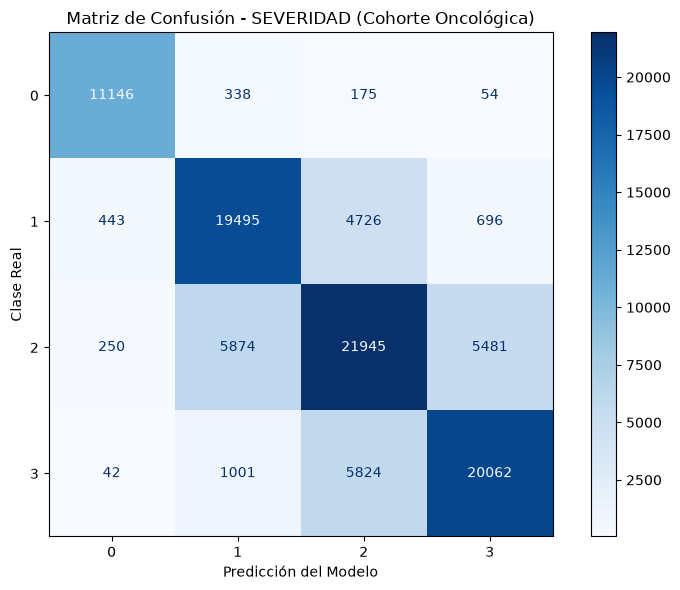


--------------------------------------------------
Evaluando modelo: CONSUMO_RECURSOS
--------------------------------------------------
-> Quadratic Weighted Kappa: 0.7011


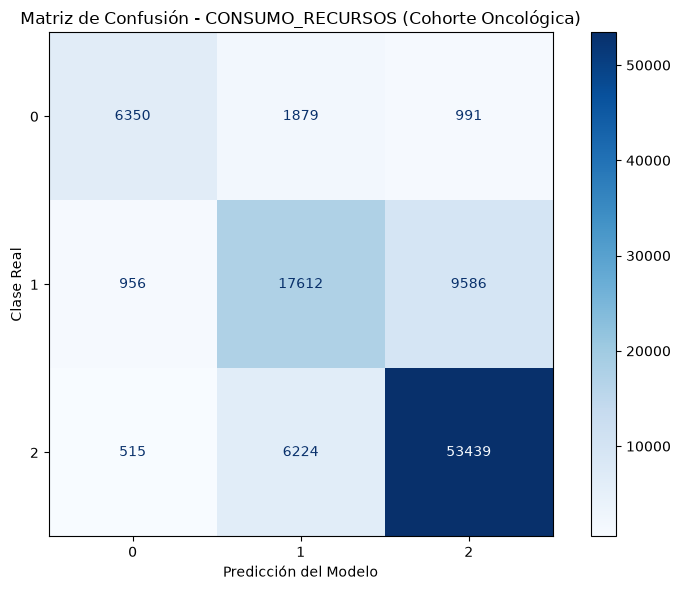

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Configuración de Rutas
dir_datos = "../../Datos/Datasets Finales"
dir_xgb = "../../Resultados/Resultados (etapa 3 y 4)/XGBoost"
# Usaremos los modelos originales que ya tienes evaluados
modelo_sev_path = os.path.join(dir_xgb, "Modelo_Optimo_XGBoost_SEVERIDAD.pkl")
modelo_cons_path = os.path.join(dir_xgb, "Modelo_Optimo_XGBoost_CONSUMO_RECURSOS.pkl")

print("=== CÁLCULO DE KAPPA PONDERADO Y MATRIZ DE CONFUSIÓN (ENFOQUE ORDINAL) ===")

# 2. Cargar Dataset de Prueba Oncológico (Que ya trae el One-Hot Encoding)
print("Cargando dataset de prueba oncológico...")
df_onco_test = pd.read_csv(os.path.join(dir_datos, "dataset_prueba_onco.csv"), low_memory=False)

# Separar X base (quitando todos los targets posibles)
X_base = df_onco_test.drop(columns=['CONSUMO_RECURSOS', 'SEVERIDAD', 'MORTALIDAD'], errors='ignore')

def evaluar_ordinal(modelo_path, X_base, y_true, target_name):
    print(f"\n{'-'*50}\nEvaluando modelo: {target_name}\n{'-'*50}")
    
    # Cargar modelo
    modelo = joblib.load(modelo_path)
    
    # Alinear columnas exactamente como las vio el modelo al entrenar
    X = X_base.reindex(columns=modelo.feature_names_in_, fill_value=0)
    
    # Predicción
    y_pred = modelo.predict(X)
    
    # 1. Calcular Quadratic Weighted Kappa
    # 'quadratic' penaliza fuertemente los errores lejanos (ej. predecir 0 cuando era 3)
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    print(f"-> Quadratic Weighted Kappa: {kappa:.4f}")
    
    # 2. Generar Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    
    # Graficar y guardar
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    fig, ax = plt.subplots(figsize=(8, 6))
    # Usamos un mapa de color suave (Blues) para que los números se lean bien
    disp.plot(cmap='Blues', ax=ax, values_format='d') 
    
    plt.title(f"Matriz de Confusión - {target_name} (Cohorte Oncológica)")
    plt.xlabel("Predicción del Modelo")
    plt.ylabel("Clase Real")
    plt.tight_layout()
    plt.show()

# 3. Ejecutar para Severidad
y_sev = df_onco_test['SEVERIDAD']
evaluar_ordinal(modelo_sev_path, X_base, y_sev, "SEVERIDAD")

# 4. Ejecutar para Consumo de Recursos
y_cons = df_onco_test['CONSUMO_RECURSOS']
evaluar_ordinal(modelo_cons_path, X_base, y_cons, "CONSUMO_RECURSOS")